# Red de Pases en Fútbol con Algoritmos de Búsqueda Heurística
**Tema / sector:** IA aplicada al Rendimiento Deportivo (fútbol profesional)

Modelamos una **jugada de construcción ofensiva**: el equipo saca el balón desde el portero (`POR`)
y debe hacerlo llegar al delantero (`DL`) para finalizar. Cada pase tiene un **riesgo de
intercepción** (escala 1–10) medido por el equipo de análisis de video sobre partidos anteriores.

**La pregunta del sector:** ¿por qué cadena de pases debe salir el equipo para llegar al delantero
**perdiendo el balón lo menos posible**?

---

## 1. Modelado del grafo

### Nodos = jugadores (formación 4-2-3-1)

| Código | Jugador | Zona | `zona` (avance) |
|--------|---------|------|-----------------|
| `POR` | Portero | Portería | 0 |
| `LTI` | Lateral izquierdo | Defensa, banda izq. | 1 |
| `DFI` | Central izquierdo | Defensa, centro | 1 |
| `DFD` | Central derecho | Defensa, centro | 1 |
| `LTD` | Lateral derecho | Defensa, banda der. | 1 |
| `MC1` | Pivote izquierdo | Mediocampo | 2 |
| `MC2` | Pivote derecho | Mediocampo | 2 |
| `EXI` | Extremo izquierdo | Último tercio, banda | 3 |
| `MO` | Mediapunta (entre líneas) | Último tercio, centro | 3 |
| `EXD` | Extremo derecho | Último tercio, banda | 3 |
| `DL` | Delantero centro | Área rival | 4 |

### Aristas = pases posibles, peso = riesgo de intercepción (1–10)

El peso **no es distancia**: es cuántas veces se pierde ese pase, según el video. Un pase corto entre
centrales es casi gratis (1); un centro al área desde la banda con tres defensas dentro es carísimo (8–9).

### Heurística h(n) — la parte que define el sector

> **h(n) = (zonas que le faltan al jugador n para llegar al área) × (riesgo mínimo por pase observado en el equipo)**
>
> es decir: **h(n) = (4 − zona(n)) × 2**

**Lectura futbolística:** *"en el mejor de los casos imaginable, cada pase que aún falta para llegar
al área saldría tan limpio como el mejor pase que este equipo sabe dar (riesgo 2). Nunca va a salir
mejor que eso."*

Es una **relajación del problema**: suponemos que todos los pases que faltan son perfectos. Por eso
**nunca sobreestima** → es admisible, y por eso A\* encontrará la jugada de mínimo riesgo.

In [3]:
import heapq
from collections import deque

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

### 1.1 Definición del grafo, de las zonas y de la heurística

> Estas tres estructuras son **la única cosa que hay que tocar** para cambiar de escenario táctico.
> Si modificas un peso (por ejemplo `('EXD', 9)` → `('EXD', 3)` para simular que el área quedó vacía)
> y vuelves a ejecutar el notebook en orden, **todos los resultados y todas las tablas se recalculan solos**.

In [4]:
# --- Aristas: (jugador_destino, riesgo_de_intercepcion_del_pase) -------------
grafo = {
    'POR': [('DFI', 2), ('DFD', 2), ('LTI', 2), ('LTD', 2)],   # saque, todo seguro
    'DFI': [('DFD', 1), ('LTI', 1), ('MC1', 2)],               # circulacion atras
    'DFD': [('DFI', 1), ('LTD', 1), ('MC2', 2)],
    'LTI': [('DFI', 1), ('MC1', 3), ('EXI', 4)],
    'LTD': [('DFD', 1), ('MC2', 3), ('EXD', 4)],
    'MC1': [('MC2', 1), ('MO', 2), ('EXI', 3)],
    'MC2': [('MC1', 1), ('MO', 3), ('EXD', 3)],
    'EXI': [('DL', 8), ('MO', 2)],                             # centro al area = carisimo
    'MO':  [('DL', 3), ('EXI', 2), ('EXD', 2)],                # pase filtrado = la via buena
    'EXD': [('DL', 9), ('MO', 2)],                             # centro al area = carisimo
    'DL':  [],
}

# --- Zona de cada jugador: 0 = porteria propia, 4 = area rival ---------------
zona = {'POR': 0,
        'LTI': 1, 'DFI': 1, 'DFD': 1, 'LTD': 1,
        'MC1': 2, 'MC2': 2,
        'EXI': 3, 'MO': 3, 'EXD': 3,
        'DL':  4}

# --- Heuristica: riesgo minimo imaginable que le falta a n para llegar al area
RIESGO_MIN_POR_PASE = 2          # el mejor pase que este equipo sabe dar
h = {n: (4 - z) * RIESGO_MIN_POR_PASE for n, z in zona.items()}

INICIO, OBJETIVO = 'POR', 'DL'

print("Heuristica h(n) — riesgo estimado que falta hasta el area:")
for n in sorted(h, key=lambda x: (zona[x], x)):
    print(f"  {n:4} zona={zona[n]}  h={h[n]:2}")

Heuristica h(n) — riesgo estimado que falta hasta el area:
  POR  zona=0  h= 8
  DFD  zona=1  h= 6
  DFI  zona=1  h= 6
  LTD  zona=1  h= 6
  LTI  zona=1  h= 6
  MC1  zona=2  h= 4
  MC2  zona=2  h= 4
  EXD  zona=3  h= 2
  EXI  zona=3  h= 2
  MO   zona=3  h= 2
  DL   zona=4  h= 0


### 1.2 Validación de la heurística

Antes de usar cualquier heurística hay que demostrar que **sirve**. Se comprueban las dos propiedades
que vimos en clase:

- **Admisible:** `h(n) ≤ h*(n)` — nunca promete menos riesgo del que realmente cuesta.
  Es lo que le garantiza a A\* que va a encontrar la jugada óptima.
- **Consistente (monótona):** `h(n) ≤ c(n,n') + h(n')` — la estimación no da saltos raros al
  avanzar un pase. Evita que A\* tenga que reprocesar jugadores ya evaluados.

`h*(n)` es el riesgo real mínimo de n al delantero; se calcula con Dijkstra sobre el grafo invertido.

In [5]:
def h_real(g, objetivo):
    """h*(n): riesgo real minimo de cada jugador hasta el objetivo (Dijkstra invertido)."""
    inverso = {n: [] for n in g}
    for origen in g:
        for destino, peso in g[origen]:
            inverso[destino].append((origen, peso))

    dist = {n: float('inf') for n in g}
    dist[objetivo] = 0
    cola = [(0, objetivo)]
    while cola:
        d, n = heapq.heappop(cola)
        if d > dist[n]:
            continue
        for previo, peso in inverso[n]:
            if d + peso < dist[previo]:
                dist[previo] = d + peso
                heapq.heappush(cola, (d + peso, previo))
    return dist


def validar_heuristica(g, hh, objetivo):
    hr = h_real(g, objetivo)

    adm = pd.DataFrame([{'jugador': n, 'h(n)': hh[n], 'h*(n)': hr[n],
                         'admisible': 'SI' if hh[n] <= hr[n] else 'NO  <-- ROMPE'}
                        for n in sorted(g, key=lambda x: (zona.get(x, 9), x))])

    fallos = [f"{a} -> {b}: {hh[a]} > {p} + {hh[b]}"
              for a in g for b, p in g[a] if hh[a] > p + hh[b]]

    print("== ADMISIBILIDAD  h(n) <= h*(n) ==")
    print(adm.to_string(index=False))
    print("\n== CONSISTENCIA  h(n) <= c(n,n') + h(n') ==")
    print("  Todas las aristas cumplen." if not fallos else "  " + "\n  ".join(fallos))
    ok = adm['admisible'].str.startswith('SI').all() and not fallos
    print(f"\n=> Heuristica {'ADMISIBLE y CONSISTENTE' if ok else 'NO VALIDA'}")
    print(f"=> Riesgo minimo real de la jugada  C* = {hr[INICIO]}")
    return hr


h_estrella = validar_heuristica(grafo, h, OBJETIVO)

== ADMISIBILIDAD  h(n) <= h*(n) ==
jugador  h(n)  h*(n) admisible
    POR     8      9        SI
    DFD     6      8        SI
    DFI     6      7        SI
    LTD     6      9        SI
    LTI     6      8        SI
    MC1     4      5        SI
    MC2     4      6        SI
    EXD     2      5        SI
    EXI     2      5        SI
     MO     2      3        SI
     DL     0      0        SI

== CONSISTENCIA  h(n) <= c(n,n') + h(n') ==
  Todas las aristas cumplen.

=> Heuristica ADMISIBLE y CONSISTENTE
=> Riesgo minimo real de la jugada  C* = 9


---

## 2. Algoritmos

Todos devuelven la **misma tupla** `(ruta, riesgo_total, nodos_expandidos)` para poder compararlos
de forma justa.

> **Nota metodológica.** Una implementación muy común de Greedy devuelve la *lista de nodos visitados*
> y la presenta como si fuera el camino. **No lo es**: es el orden de expansión, e incluye ramas que el
> algoritmo abrió y luego abandonó. Aquí todos los algoritmos guardan un diccionario `padre` y
> **reconstruyen la ruta real** hacia atrás desde el objetivo. Sin eso, la comparación de "longitud del
> camino" mide cosas distintas en cada algoritmo.

In [6]:
def reconstruir(padre, objetivo):
    """Camino real inicio->objetivo siguiendo los punteros al padre."""
    ruta, n = [], objetivo
    while n is not None:
        ruta.append(n)
        n = padre[n]
    return ruta[::-1]


def costo_ruta(g, ruta):
    """Riesgo acumulado de una cadena de pases."""
    if len(ruta) < 2:
        return 0
    return sum(next(p for d, p in g[a] if d == b) for a, b in zip(ruta, ruta[1:]))

In [7]:
# ============================ BUSQUEDA CIEGA ================================
def bfs(g, inicio, objetivo):
    """Menos pases posibles, ignorando el riesgo."""
    padre = {inicio: None}
    cola, expandidos = deque([inicio]), 0
    while cola:
        n = cola.popleft()
        expandidos += 1
        if n == objetivo:
            r = reconstruir(padre, objetivo)
            return r, costo_ruta(g, r), expandidos
        for v, _ in g[n]:
            if v not in padre:
                padre[v] = n
                cola.append(v)
    return [], float('inf'), expandidos


def dfs(g, inicio, objetivo):
    """Se lanza por la primera rama que encuentra, sin criterio."""
    padre = {inicio: None}
    pila, visitados, expandidos = [inicio], set(), 0
    while pila:
        n = pila.pop()
        if n in visitados:
            continue
        visitados.add(n)
        expandidos += 1
        if n == objetivo:
            r = reconstruir(padre, objetivo)
            return r, costo_ruta(g, r), expandidos
        for v, _ in reversed(g[n]):
            if v not in visitados:
                padre[v] = n
                pila.append(v)
    return [], float('inf'), expandidos


def ucs(g, inicio, objetivo):
    """Costo uniforme: f(n) = g(n). Optimo, pero explora a ciegas en todas direcciones."""
    padre = {inicio: None}
    g_score = {inicio: 0}
    frontera, visitados, expandidos = [(0, inicio)], set(), 0
    while frontera:
        costo, n = heapq.heappop(frontera)
        if n in visitados:
            continue
        visitados.add(n)
        expandidos += 1
        if n == objetivo:
            return reconstruir(padre, objetivo), costo, expandidos
        for v, peso in g[n]:
            if costo + peso < g_score.get(v, float('inf')):
                g_score[v] = costo + peso
                padre[v] = n
                heapq.heappush(frontera, (costo + peso, v))
    return [], float('inf'), expandidos

In [8]:
# ============================ BUSQUEDA HEURISTICA ===========================
def greedy(g, hh, inicio, objetivo):
    """Greedy Best-First:  f(n) = h(n).   Solo mira lo que falta, ignora lo gastado."""
    padre = {inicio: None}
    frontera = [(hh[inicio], inicio)]                       # prioridad = h(n) sola
    visitados, expandidos = set(), 0
    while frontera:
        _, n = heapq.heappop(frontera)
        if n in visitados:
            continue
        visitados.add(n)
        expandidos += 1
        if n == objetivo:
            r = reconstruir(padre, objetivo)
            return r, costo_ruta(g, r), expandidos
        for v, _peso in g[n]:
            if v not in visitados and v not in padre:
                padre[v] = n
                heapq.heappush(frontera, (hh[v], v))        # el peso del pase NO entra
    return [], float('inf'), expandidos


def a_estrella(g, hh, inicio, objetivo, w=1.0):
    """A* y Weighted A* en una sola funcion:  f(n) = g(n) + w * h(n).

    w = 1.0  -> A* clasico: optimo si h es admisible.
    w > 1.0  -> Weighted A*: confia mas en la heuristica, va mas rapido,
                y garantiza costo <= w * C* (suboptimo acotado).
    """
    padre = {inicio: None}
    g_score = {n: float('inf') for n in g}
    g_score[inicio] = 0
    frontera = [(w * hh[inicio], inicio)]
    visitados, expandidos = set(), 0
    while frontera:
        _, n = heapq.heappop(frontera)
        if n in visitados:
            continue
        visitados.add(n)
        expandidos += 1
        if n == objetivo:
            return reconstruir(padre, objetivo), g_score[n], expandidos
        for v, peso in g[n]:
            if v in visitados:
                continue
            nuevo = g_score[n] + peso                       # g(n) real acumulado
            if nuevo < g_score[v]:
                g_score[v] = nuevo
                padre[v] = n
                heapq.heappush(frontera, (nuevo + w * hh[v], v))   # f = g + w*h
    return [], float('inf'), expandidos

---

## 3. Dibujo del grafo

Colores: la ruta encontrada se resalta sobre el resto de la red de pases.

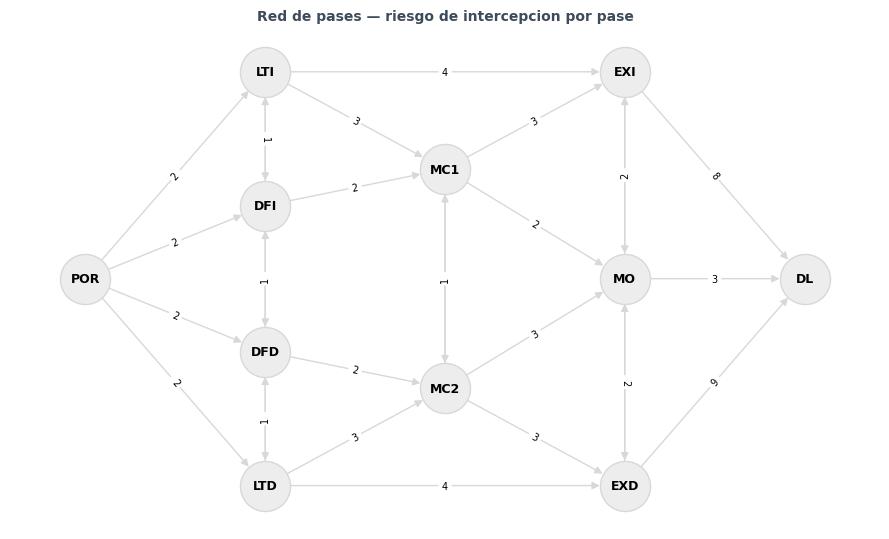

In [9]:
ROJO, AZUL, CLARO, FONDO = '#EE2A49', '#3E4B5B', '#D8D8D8', '#EDEDED'

posiciones = {
    'POR': (0, 2.5),
    'LTI': (1, 4.2), 'DFI': (1, 3.1), 'DFD': (1, 1.9), 'LTD': (1, 0.8),
    'MC1': (2, 3.4), 'MC2': (2, 1.6),
    'EXI': (3, 4.2), 'MO':  (3, 2.5), 'EXD': (3, 0.8),
    'DL':  (4, 2.5),
}


def construir_G(g):
    G = nx.DiGraph()
    for origen, destinos in g.items():
        for destino, peso in destinos:
            G.add_edge(origen, destino, weight=peso)
    return G


def dibujar(ax, g, ruta, titulo, color=ROJO):
    G = construir_G(g)
    pos = {n: p for n, p in posiciones.items() if n in G}
    nx.draw(G, pos, ax=ax, with_labels=True, node_color=FONDO, edgecolors=CLARO,
            node_size=1300, font_size=9, font_weight='bold',
            edge_color=CLARO, arrows=True, arrowsize=11)
    nx.draw_networkx_edge_labels(G, pos, ax=ax, font_size=7,
                                 edge_labels=nx.get_edge_attributes(G, 'weight'))
    if ruta:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=list(zip(ruta, ruta[1:])),
                               edge_color=color, width=3, arrows=True, arrowsize=15)
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=ruta, node_color=color,
                               node_size=1300, edgecolors=color)
        nx.draw_networkx_labels(G, pos, ax=ax, labels={n: n for n in ruta},
                                font_size=9, font_weight='bold', font_color='white')
    ax.set_title(titulo, fontsize=10, fontweight='bold', color=AZUL)


G = construir_G(grafo)
fig, ax = plt.subplots(figsize=(9, 5.5))
dibujar(ax, grafo, [], "Red de pases — riesgo de intercepcion por pase")
plt.tight_layout(); plt.show()

### 3.1 Punto de partida: las tres búsquedas ciegas

Sirven de línea base: es lo que hace un algoritmo **sin heurística**.

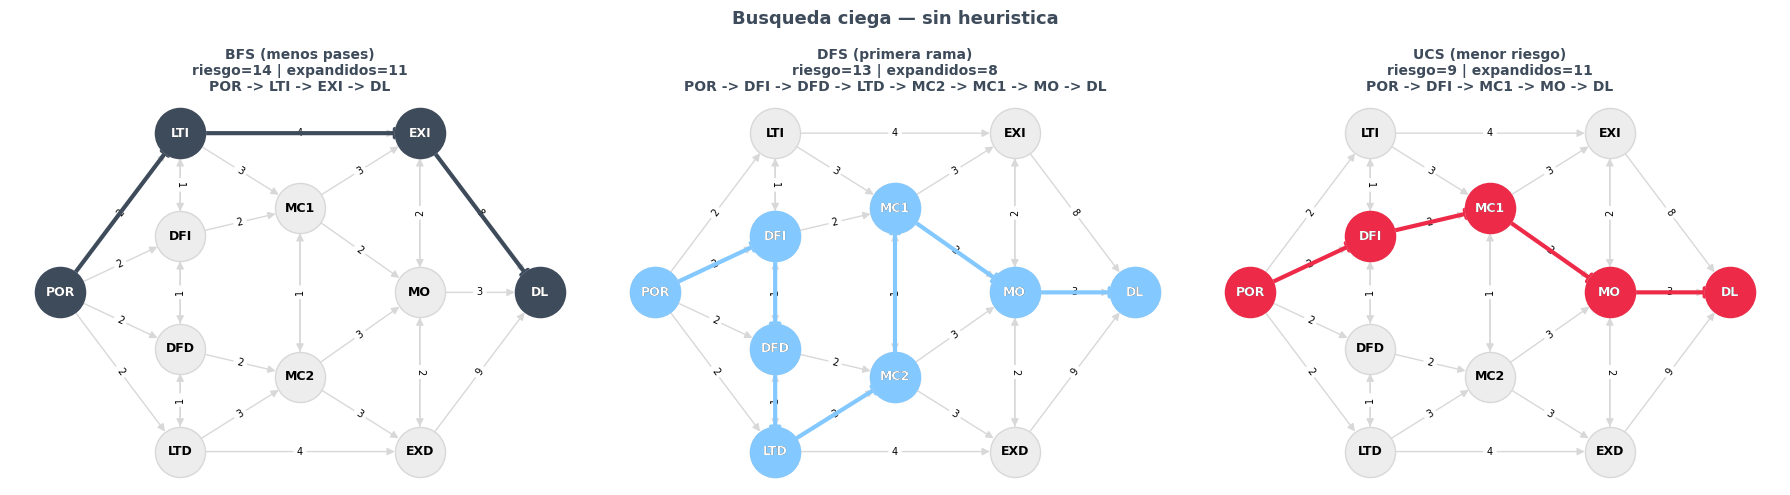

In [10]:
rutas_ciegas = {
    'BFS (menos pases)': (bfs(grafo, INICIO, OBJETIVO), AZUL),
    'DFS (primera rama)': (dfs(grafo, INICIO, OBJETIVO), '#83C8FF'),
    'UCS (menor riesgo)': (ucs(grafo, INICIO, OBJETIVO), ROJO),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nombre, ((ruta, costo, exp), color)) in zip(axes, rutas_ciegas.items()):
    dibujar(ax, grafo, ruta, f"{nombre}\nriesgo={costo} | expandidos={exp}\n{' -> '.join(ruta)}", color)
plt.suptitle("Busqueda ciega — sin heuristica", fontsize=13, fontweight='bold', color=AZUL)
plt.tight_layout(); plt.show()

---

# RETO 1 — Comparativa de rendimiento

Ejecutamos **Greedy**, **A\*** y **Weighted A\*** sobre el mismo grafo y medimos:

- **Nodos expandidos** → cuánto le costó pensar (proxy directo del tiempo de cómputo).
- **Longitud del camino** → se reporta en las dos formas que tiene sentido en este sector:
  **número de pases** (saltos) y **riesgo acumulado** (costo real de la jugada).

Los pesos `w` no se toman de la teoría, se eligen por lo que significan **en fútbol**:

| w | Lectura táctica |
|---|---|
| `1.0` | Equipo con el partido controlado: prioriza no perder el balón por encima de todo. |
| `1.5` | Equipo que necesita acelerar: acepta algo más de riesgo con tal de progresar. |
| `2.0` | Equipo que va perdiendo y se lanza: le cree al desmarque más que al informe de riesgo. |

In [13]:
resultados_r1 = [
    ('BFS',            bfs(grafo, INICIO, OBJETIVO)),
    ('DFS',            dfs(grafo, INICIO, OBJETIVO)),
    ('UCS',            ucs(grafo, INICIO, OBJETIVO)),
    ('Greedy',         greedy(grafo, h, INICIO, OBJETIVO)),
    ('A* (w=1.0)',     a_estrella(grafo, h, INICIO, OBJETIVO, 1.0)),
    ('Weighted A* w=1.5', a_estrella(grafo, h, INICIO, OBJETIVO, 1.5)),
    ('Weighted A* w=2.0', a_estrella(grafo, h, INICIO, OBJETIVO, 2.0)),
]

C_OPTIMO = a_estrella(grafo, h, INICIO, OBJETIVO, 1.0)[1]

tabla_r1 = pd.DataFrame([{
    'Algoritmo': nombre,
    'Jugada encontrada': ' -> '.join(ruta),
    'Pases': len(ruta) - 1,
    'Riesgo acumulado': costo,
    'Nodos expandidos': exp,
    'Optimo': 'SI' if costo == C_OPTIMO else f'NO (+{100*(costo-C_OPTIMO)/C_OPTIMO:.0f}%)',
} for nombre, (ruta, costo, exp) in resultados_r1])

print(f"Riesgo minimo posible de la jugada:  C* = {C_OPTIMO}\n")
print(tabla_r1.to_string(index=False))

Riesgo minimo posible de la jugada:  C* = 9

        Algoritmo                                  Jugada encontrada  Pases  Riesgo acumulado  Nodos expandidos    Optimo
              BFS                            POR -> LTI -> EXI -> DL      3                14                11 NO (+56%)
              DFS POR -> DFI -> DFD -> LTD -> MC2 -> MC1 -> MO -> DL      7                13                 8 NO (+44%)
              UCS                      POR -> DFI -> MC1 -> MO -> DL      4                 9                11        SI
           Greedy                     POR -> DFD -> MC2 -> EXD -> DL      4                16                 5 NO (+78%)
       A* (w=1.0)                      POR -> DFI -> MC1 -> MO -> DL      4                 9                11        SI
Weighted A* w=1.5                      POR -> DFD -> MC2 -> MO -> DL      4                10                 6 NO (+11%)
Weighted A* w=2.0                      POR -> DFD -> MC2 -> MO -> DL      4                10        

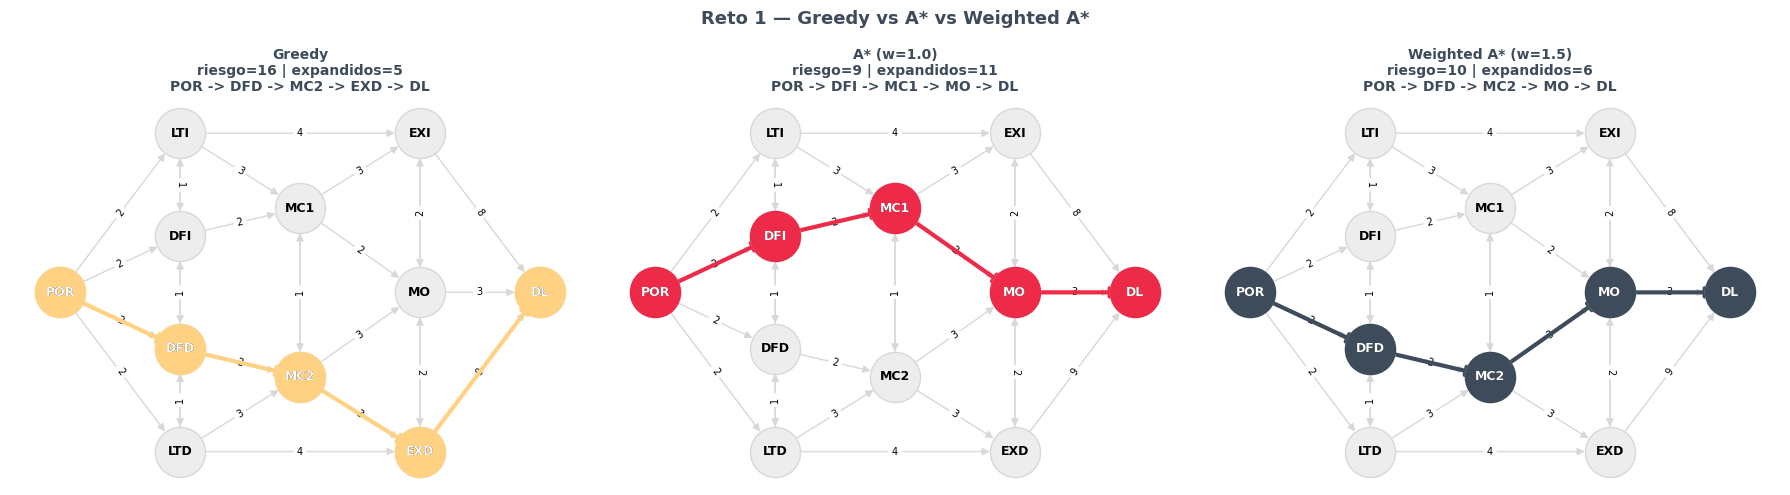

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
comparar = [('Greedy', greedy(grafo, h, INICIO, OBJETIVO), '#FFD283'),
            ('A* (w=1.0)', a_estrella(grafo, h, INICIO, OBJETIVO, 1.0), ROJO),
            ('Weighted A* (w=1.5)', a_estrella(grafo, h, INICIO, OBJETIVO, 1.5), AZUL)]
for ax, (nombre, (ruta, costo, exp), color) in zip(axes, comparar):
    dibujar(ax, grafo, ruta, f"{nombre}\nriesgo={costo} | expandidos={exp}\n{' -> '.join(ruta)}", color)
plt.suptitle("Reto 1 — Greedy vs A* vs Weighted A*", fontsize=13, fontweight='bold', color=AZUL)
plt.tight_layout(); plt.show()

### Lectura del Reto 1

**Greedy se comió el anzuelo.** Fue el más rápido (5 jugadores evaluados de 11), pero eligió
`POR → DFD → MC2 → EXD → DL`, con riesgo **16** frente al mínimo de **9**: casi el doble.

El motivo es exactamente el de la diapositiva del *atajo peligroso*: el extremo derecho `EXD` está
pegado al área, así que su `h` es bajísimo (2) y Greedy lo ve como "casi gol". Lo que Greedy **no
mira** es que el único pase que sale de `EXD` es un centro al área con riesgo **9**. Traducido al
campo: *el algoritmo manda centrar desde la banda porque el extremo "está cerca del arco",
ignorando que hay tres centrales esperando el centro.*

**A\* no cae** porque suma `g(n)`: ve que llegar a `EXD` ya costó y que rematar desde ahí cuesta 9,
así que prefiere `POR → DFI → MC1 → MO → DL` — la salida por dentro con el mediapunta. Riesgo **9**,
el óptimo. Lo paga expandiendo los 11 jugadores.

**Weighted A\* queda en medio**, que es justo para lo que existe: riesgo 10 (+11 %) evaluando 6
jugadores en vez de 11 (−45 %).

---

# RETO 2 — Ajuste del peso (trade-off)

Ejecutamos Weighted A\* con **w = 1, 1.2, 1.5, 2, 3** y graficamos las dos curvas.

Además mostramos la **cota teórica de suboptimalidad**: con una heurística admisible, Weighted A\*
garantiza `costo ≤ w · C*`. Es la promesa formal del algoritmo, y sirve para saber cuánto riesgo
extra estamos autorizando *antes* de ejecutarlo.

In [15]:
W_LISTA = [1, 1.2, 1.5, 2, 3]

barrido = []
for w in W_LISTA:
    ruta, costo, exp = a_estrella(grafo, h, INICIO, OBJETIVO, w)
    barrido.append({'w': w, 'Riesgo del camino': costo, 'Nodos expandidos': exp,
                    'Desvio real': f'+{100*(costo-C_OPTIMO)/C_OPTIMO:.1f}%',
                    'Cota w*C*': round(w * C_OPTIMO, 1),
                    'Jugada': ' -> '.join(ruta)})

tabla_r2 = pd.DataFrame(barrido)
print(tabla_r2.to_string(index=False))

  w  Riesgo del camino  Nodos expandidos Desvio real  Cota w*C*                        Jugada
1.0                  9                11       +0.0%        9.0 POR -> DFI -> MC1 -> MO -> DL
1.2                  9                 7       +0.0%       10.8 POR -> DFI -> MC1 -> MO -> DL
1.5                 10                 6      +11.1%       13.5 POR -> DFD -> MC2 -> MO -> DL
2.0                 10                 6      +11.1%       18.0 POR -> DFD -> MC2 -> MO -> DL
3.0                 10                 6      +11.1%       27.0 POR -> DFD -> MC2 -> MO -> DL


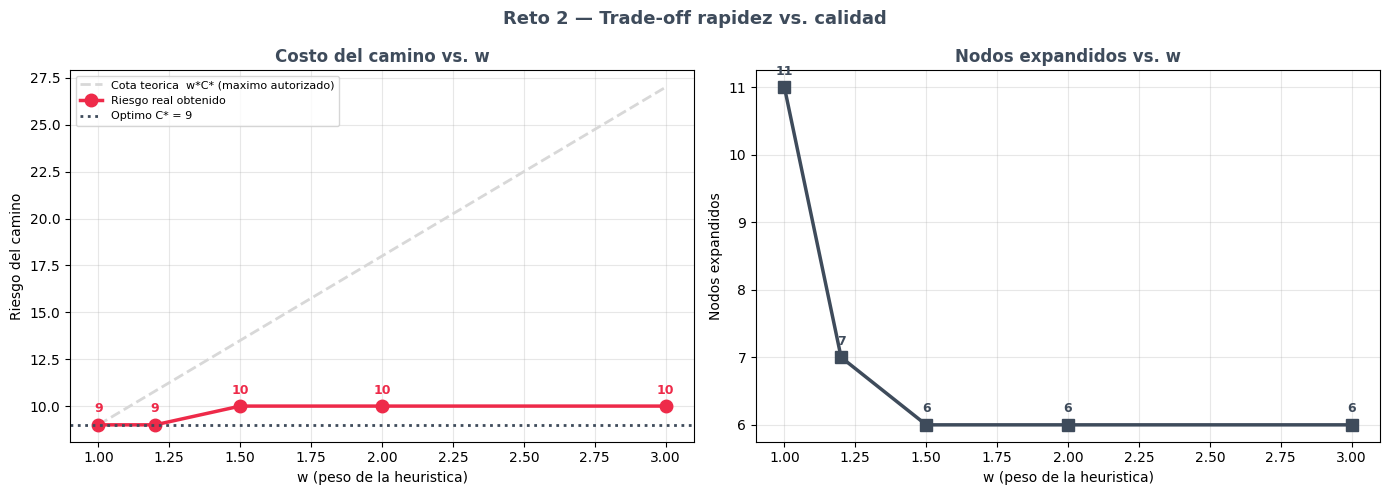

In [16]:
ws     = [f['w'] for f in barrido]
costos = [f['Riesgo del camino'] for f in barrido]
nodos  = [f['Nodos expandidos'] for f in barrido]
cotas  = [f['Cota w*C*'] for f in barrido]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ws, cotas, '--', color=CLARO, lw=2, label='Cota teorica  w*C* (maximo autorizado)')
ax1.plot(ws, costos, 'o-', color=ROJO, lw=2.5, ms=9, label='Riesgo real obtenido')
ax1.axhline(C_OPTIMO, color=AZUL, ls=':', lw=2, label=f'Optimo C* = {C_OPTIMO}')
ax1.set_xlabel('w (peso de la heuristica)'); ax1.set_ylabel('Riesgo del camino')
ax1.set_title('Costo del camino vs. w', fontweight='bold', color=AZUL)
ax1.legend(fontsize=8); ax1.grid(alpha=.3)
for x, y in zip(ws, costos):
    ax1.annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 9),
                 ha='center', fontsize=9, fontweight='bold', color=ROJO)

ax2.plot(ws, nodos, 's-', color=AZUL, lw=2.5, ms=9)
ax2.set_xlabel('w (peso de la heuristica)'); ax2.set_ylabel('Nodos expandidos')
ax2.set_title('Nodos expandidos vs. w', fontweight='bold', color=AZUL)
ax2.grid(alpha=.3)
for x, y in zip(ws, nodos):
    ax2.annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 9),
                 ha='center', fontsize=9, fontweight='bold', color=AZUL)

plt.suptitle('Reto 2 — Trade-off rapidez vs. calidad', fontsize=13, fontweight='bold', color=AZUL)
plt.tight_layout(); plt.show()

In [17]:
# Barrido fino: la curva NO es monotona, conviene verlo
fino = [(w, *a_estrella(grafo, h, INICIO, OBJETIVO, w)[1:]) for w in
        [1, 1.1, 1.2, 1.3, 1.4, 1.5, 2, 3, 4, 5]]
print(pd.DataFrame(fino, columns=['w', 'Riesgo', 'Expandidos']).to_string(index=False))

  w  Riesgo  Expandidos
1.0       9          11
1.1       9          11
1.2       9           7
1.3      10          11
1.4      10           6
1.5      10           6
2.0      10           6
3.0      10           6
4.0      10           6
5.0      16           5


### ¿Qué peso logra el mejor balance entre rapidez y calidad?

**w = 1.2.** Encuentra exactamente la misma jugada óptima que A\* (riesgo **9**) evaluando **7**
jugadores en vez de **11**: **36 % menos cómputo y cero pérdida de calidad**. Es el mejor balance
porque es gratis — no se paga nada por ir más rápido.

Si se prioriza la velocidad por encima de todo, **w = 1.5** baja a **6** nodos (−45 %) a cambio de
**+11 %** de riesgo (9 → 10). Es una jugada distinta pero perfectamente jugable: sale por el otro
central. En una escala de riesgo de 1 a 10, +1 punto sobre una jugada de 4 pases es asumible.

**A partir de w = 5 el algoritmo colapsa en Greedy**: mismo camino, mismo riesgo 16. Ahí ya se perdió
el sentido de usar A\*.

> **Detalle importante que muestra el barrido fino: la curva no es monótona.** En `w = 1.3` los nodos
> expandidos *suben* a 11 en vez de bajar. No es un error: al inflar `h`, el orden de la cola de
> prioridad se reordena por completo, y con desempates distintos el algoritmo puede meterse a
> explorar las bandas (`EXI`, `EXD`) antes de descartarlas. **Conclusión práctica: el `w` no se
> deduce, se mide.** Hay que barrerlo sobre el grafo real, como aquí.

---

# RETO 3 — Escenario dinámico

Un partido no es estático. Simulamos dos cambios reales y recalculamos con cada algoritmo:

- **Escenario A — marca personal sobre el mediapunta.** El rival detecta que `MO` es la llave de la
  jugada y le pone un jugador encima. Todo pase **hacia** `MO` sube su riesgo en **+5**.
  *(cambio en los costos `g`, la topología no cambia)*
- **Escenario B — el mediapunta sale del campo.** Lesión o expulsión: `MO` desaparece del grafo.
  *(cambio en la topología)*

In [18]:
# --- Escenario A: marca personal sobre MO (+5 a todo pase que llegue a MO) ---
grafo_A = {a: [(b, p + (5 if b == 'MO' else 0)) for b, p in v] for a, v in grafo.items()}
h_A = h

# --- Escenario B: MO sale del campo (nodo bloqueado) ------------------------
grafo_B = {a: [(b, p) for b, p in v if b != 'MO'] for a, v in grafo.items() if a != 'MO'}
h_B = {n: v for n, v in h.items() if n != 'MO'}

ESCENARIOS = [
    ('0. Partido normal (referencia)', grafo, h),
    ('A. Marca personal sobre MO',     grafo_A, h_A),
    ('B. MO sale del campo',           grafo_B, h_B),
]

filas = []
for titulo, gg, hh in ESCENARIOS:
    c_opt = h_real(gg, OBJETIVO)[INICIO]
    for nombre, (ruta, costo, exp) in [
            ('Greedy',              greedy(gg, hh, INICIO, OBJETIVO)),
            ('A* (w=1.0)',          a_estrella(gg, hh, INICIO, OBJETIVO, 1.0)),
            ('Weighted A* (w=1.2)', a_estrella(gg, hh, INICIO, OBJETIVO, 1.2)),
            ('Weighted A* (w=1.5)', a_estrella(gg, hh, INICIO, OBJETIVO, 1.5)),
            ('Weighted A* (w=2.0)', a_estrella(gg, hh, INICIO, OBJETIVO, 2.0))]:
        filas.append({'Escenario': titulo, 'Algoritmo': nombre,
                      'Jugada': ' -> '.join(ruta), 'Riesgo': costo,
                      'C* del escenario': c_opt,
                      'Encontro el optimo': 'SI' if costo == c_opt else 'NO',
                      'Expandidos': exp})

tabla_r3 = pd.DataFrame(filas)
for titulo, _, _ in ESCENARIOS:
    print(f"\n=== {titulo} ===")
    print(tabla_r3[tabla_r3.Escenario == titulo].drop(columns='Escenario').to_string(index=False))


=== 0. Partido normal (referencia) ===
          Algoritmo                         Jugada  Riesgo  C* del escenario Encontro el optimo  Expandidos
             Greedy POR -> DFD -> MC2 -> EXD -> DL      16                 9                 NO           5
         A* (w=1.0)  POR -> DFI -> MC1 -> MO -> DL       9                 9                 SI          11
Weighted A* (w=1.2)  POR -> DFI -> MC1 -> MO -> DL       9                 9                 SI           7
Weighted A* (w=1.5)  POR -> DFD -> MC2 -> MO -> DL      10                 9                 NO           6
Weighted A* (w=2.0)  POR -> DFD -> MC2 -> MO -> DL      10                 9                 NO           6

=== A. Marca personal sobre MO ===
          Algoritmo                         Jugada  Riesgo  C* del escenario Encontro el optimo  Expandidos
             Greedy POR -> DFD -> MC2 -> EXD -> DL      16                14                 NO           5
         A* (w=1.0)        POR -> LTI -> EXI -> DL      14  

In [19]:
# La heuristica sigue siendo valida despues del cambio?
for titulo, gg, hh in ESCENARIOS[1:]:
    hr = h_real(gg, OBJETIVO)
    ok_adm = all(hh[n] <= hr[n] for n in gg)
    ok_con = not [1 for a in gg for b, p in gg[a] if hh[a] > p + hh[b]]
    print(f"{titulo:35} admisible={'SI' if ok_adm else 'NO'}  consistente={'SI' if ok_con else 'NO'}"
          f"  C*: {h_real(grafo, OBJETIVO)[INICIO]} -> {hr[INICIO]}")

A. Marca personal sobre MO          admisible=SI  consistente=SI  C*: 9 -> 14
B. MO sale del campo                admisible=SI  consistente=SI  C*: 9 -> 14


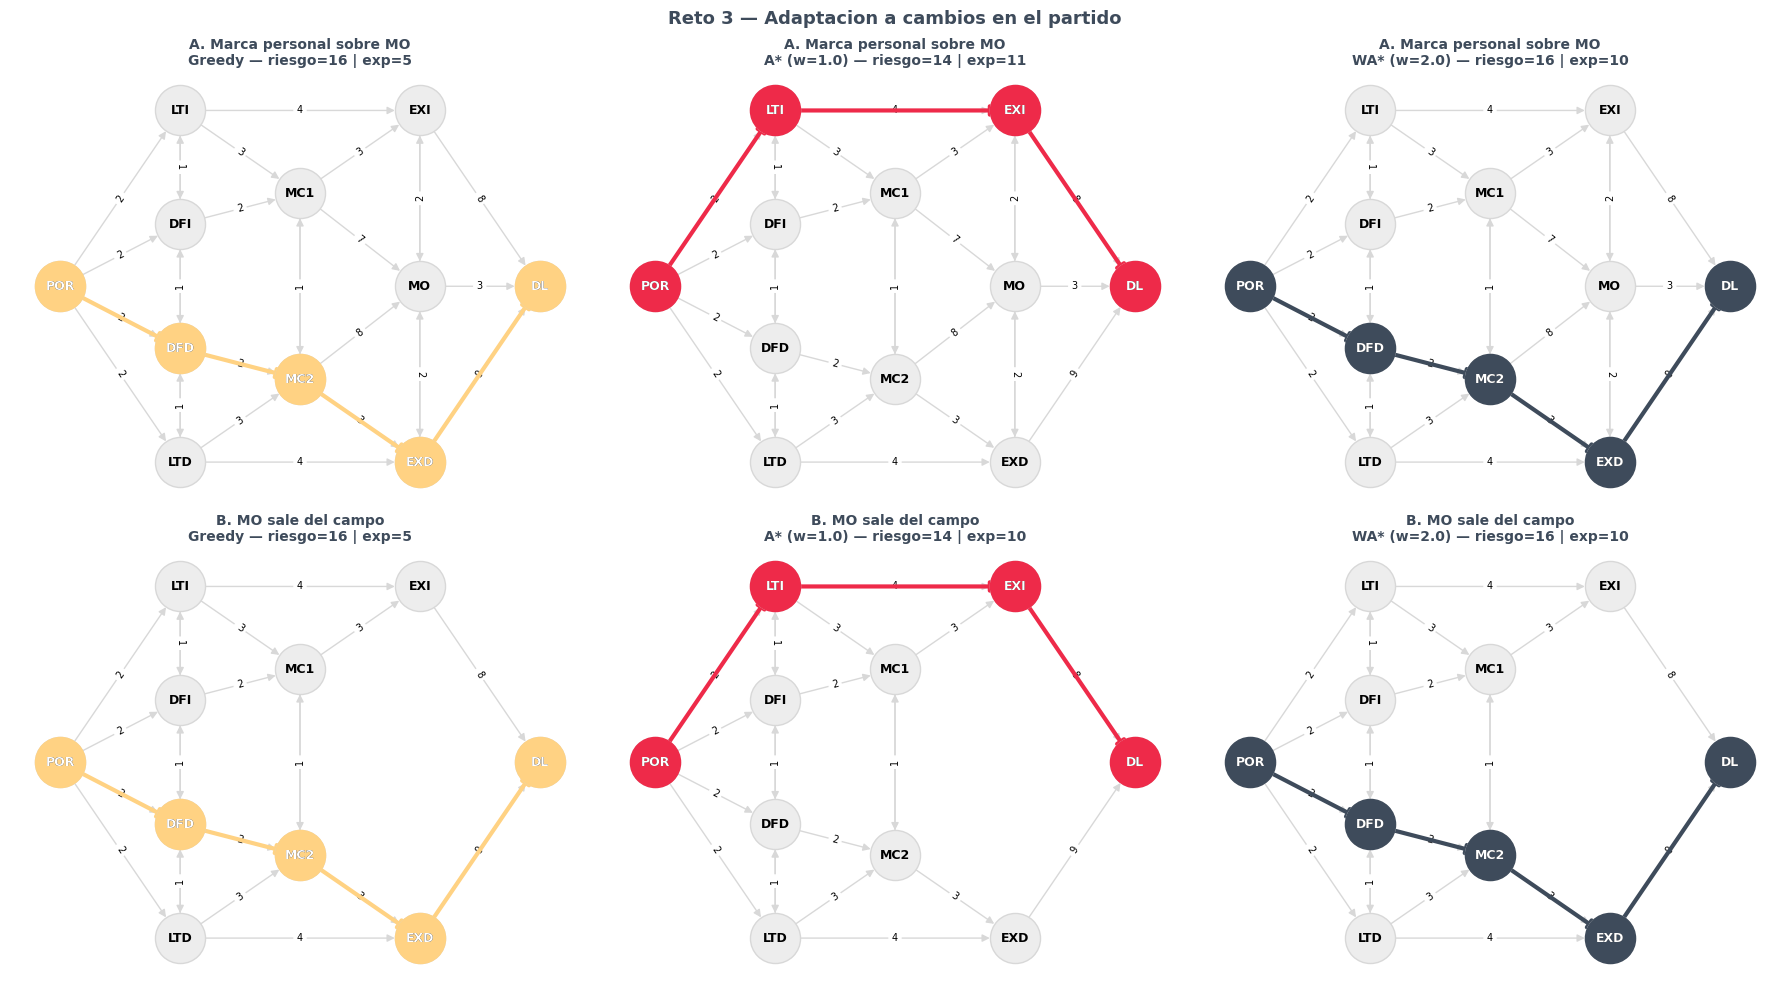

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for fila_ax, (titulo, gg, hh) in zip(axes, ESCENARIOS[1:]):
    for ax, (nombre, res, color) in zip(fila_ax, [
            ('Greedy',       greedy(gg, hh, INICIO, OBJETIVO),            '#FFD283'),
            ('A* (w=1.0)',   a_estrella(gg, hh, INICIO, OBJETIVO, 1.0),   ROJO),
            ('WA* (w=2.0)',  a_estrella(gg, hh, INICIO, OBJETIVO, 2.0),   AZUL)]):
        ruta, costo, exp = res
        dibujar(ax, gg, ruta, f"{titulo}\n{nombre} — riesgo={costo} | exp={exp}", color)
plt.suptitle("Reto 3 — Adaptacion a cambios en el partido", fontsize=13, fontweight='bold', color=AZUL)
plt.tight_layout(); plt.show()

### Análisis del Reto 3

#### ¿Cuál algoritmo se adapta mejor?

**A\*, sin discusión.** En los dos escenarios encuentra el nuevo óptimo (riesgo **14**), que ya no es
la jugada de antes: al cerrarse el pasillo del mediapunta, la mejor salida pasa a ser por la banda
izquierda, `POR → LTI → EXI → DL`.

**Greedy no se adapta: literalmente no se entera.** Devuelve la misma jugada (`POR → DFD → MC2 → EXD → DL`,
riesgo 16) en los tres escenarios, incluso en el B, donde un jugador **desapareció del campo**.

La razón es la esencia de Greedy: su función de decisión es `f(n) = h(n)`, y **`h` no cambió** —
sigue siendo "cuántas zonas te faltan × 2", porque los jugadores no se movieron de zona. Lo que
cambió fue `g`, el riesgo de los pases, y **Greedy no mira `g`**. Un algoritmo que solo usa la
estimación es ciego a cualquier cambio que ocurra en los costos reales.

> **Esta es la lección central del reto:** en un entorno dinámico, un algoritmo puramente heurístico
> no es "rápido pero aproximado" — es **inservible**, porque no reacciona. La adaptabilidad viene de
> `g(n)`, no de `h(n)`.

#### ¿Qué pasa con los costos?

El riesgo mínimo sube de **9 a 14** (+56 %) en ambos escenarios, y **la cifra es idéntica**: marcar
a un jugador y expulsarlo tuvieron el mismo efecto. Es un resultado con lectura táctica directa:
*una marca personal bien puesta sobre el hombre clave le cuesta al rival lo mismo que quedarse sin
ese jugador.* Vale la pena gastar un jugador en esa marca.

| | Partido normal | Marca sobre MO | MO fuera |
|---|---|---|---|
| **C\* (riesgo mínimo)** | 9 | 14 | 14 |
| **A\*** | 9 ✅ | 14 ✅ | 14 ✅ |
| **Weighted A\* w=1.2** | 9 ✅ | 14 ✅ | 14 ✅ |
| **Weighted A\* w=1.5** | 10 | 14 ✅ | 15 |
| **Weighted A\* w=2.0** | 10 | 16 ❌ | 16 ❌ |
| **Greedy** | 16 ❌ | 16 ❌ | 16 ❌ |

#### Impacto de la heurística en la adaptabilidad

1. **Una heurística admisible sobrevive a que el problema empeore.** Verificamos arriba que `h` sigue
   siendo admisible y consistente en los dos escenarios. No es casualidad: **encarecer aristas o
   quitar nodos solo puede subir `h*`**, y si `h ≤ h*` antes, con más razón después. Por eso A\* sigue
   dando el óptimo sin tocar una línea de código.
   **El caso peligroso es el contrario:** si un pase se vuelve *más barato* de lo que la heurística
   suponía (por ejemplo, si `RIESGO_MIN_POR_PASE` se queda desactualizado porque el equipo mejoró),
   `h` puede pasar a sobreestimar y A\* deja de garantizar el óptimo. **La heurística hay que
   recalibrarla cuando el equipo cambia, no cuando el rival cambia.**

2. **Cuanto más se infla `w`, menos se adapta.** Se ve en la tabla: `w = 1.2` acompaña a A\* en los
   tres escenarios; `w = 2.0` aguanta el partido normal pero se rompe en cuanto algo cambia y cae al
   mismo error que Greedy. **Inflar `h` es acercarse a Greedy, y Greedy es el que no reacciona.**
   En un sistema que corre en vivo sobre un partido que cambia, esto es un argumento fuerte para
   mantener `w` bajo.

---

# RETO 4 — Aplicación práctica: asistente táctico de banquillo

**El producto.** Una tablet en el banquillo recibe el posicionamiento de los jugadores en tiempo real.
Cada vez que el equipo recupera el balón, el sistema debe responder en menos de un segundo:
**"la salida más segura desde donde estás es esta"**.

La restricción de negocio es la misma que la del GPS de la diapositiva: **no sirve la ruta perfecta
calculada tarde.** Si el sistema tarda, el jugador ya pasó el balón. Por eso el algoritmo es
**Weighted A\***, y por eso hay que elegir `w` con datos, no por intuición.

### Cómo elegir `w` con evidencia

En un partido el balón se recupera en cualquier posición, no solo en el portero. Así que el `w` no se
puede calibrar con una sola jugada: hay que evaluarlo sobre **todos los orígenes posibles** — cada
jugador como punto de recuperación — y mirar el agregado.

In [21]:
ORIGENES = [n for n in grafo if n != OBJETIVO]     # el balon se puede recuperar en cualquier jugador
OPTIMOS  = {s: a_estrella(grafo, h, s, OBJETIVO, 1.0)[1] for s in ORIGENES}
BASE_NODOS = sum(a_estrella(grafo, h, s, OBJETIVO, 1.0)[2] for s in ORIGENES)   # computo de A*

calibracion = []
for w in [1, 1.1, 1.2, 1.3, 1.5, 2, 3, 5]:
    riesgo_total = nodos_total = 0
    desvios = []
    for s in ORIGENES:
        _, costo, exp = a_estrella(grafo, h, s, OBJETIVO, w)
        riesgo_total += costo
        nodos_total  += exp
        desvios.append(100 * (costo - OPTIMOS[s]) / OPTIMOS[s])
    calibracion.append({
        'w': w,
        'Riesgo total': riesgo_total,
        'Nodos expandidos (total)': nodos_total,
        'Ahorro de computo': '—' if w == 1 else f"-{100*(BASE_NODOS-nodos_total)/BASE_NODOS:.0f}%",
        'Desvio medio': f"{sum(desvios)/len(desvios):.1f}%",
        'Peor caso': f"{max(desvios):.1f}%",
    })

tabla_r4 = pd.DataFrame(calibracion)
print(f"Calibracion de w sobre las {len(ORIGENES)} recuperaciones posibles:\n")
print(tabla_r4.to_string(index=False))

Calibracion de w sobre las 10 recuperaciones posibles:

  w  Riesgo total  Nodos expandidos (total) Ahorro de computo Desvio medio Peor caso
1.0            65                        55                 —         0.0%      0.0%
1.1            65                        53               -4%         0.0%      0.0%
1.2            65                        45              -18%         0.0%      0.0%
1.3            66                        46              -16%         1.1%     11.1%
1.5            66                        40              -27%         1.1%     11.1%
2.0            67                        38              -31%         2.4%     12.5%
3.0            73                        36              -35%        12.1%     60.0%
5.0            99                        31              -44%        48.7%    100.0%


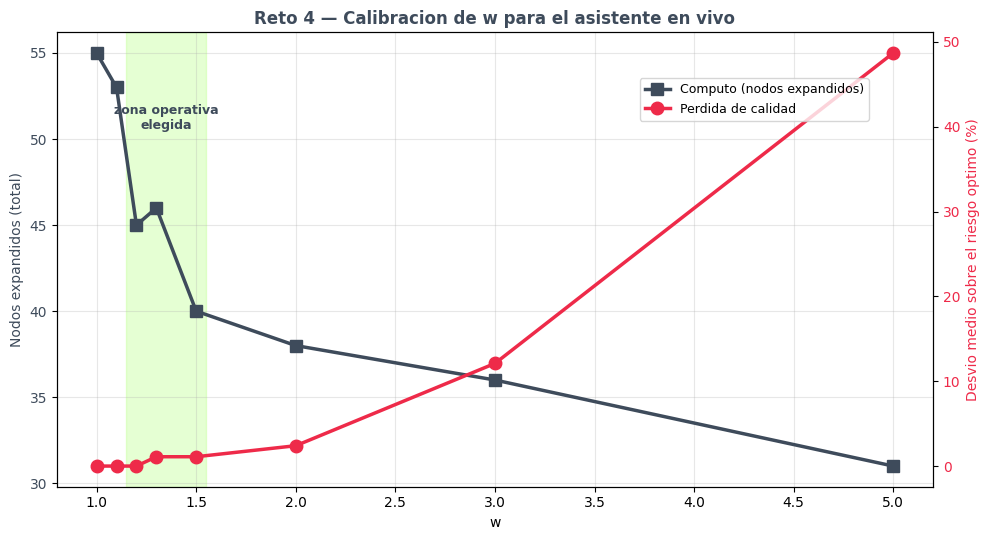

In [22]:
ws_c    = [f['w'] for f in calibracion]
nodos_c = [f['Nodos expandidos (total)'] for f in calibracion]
desv_c  = [float(f['Desvio medio'].rstrip('%')) for f in calibracion]

fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax1.plot(ws_c, nodos_c, 's-', color=AZUL, lw=2.5, ms=9, label='Computo (nodos expandidos)')
ax1.set_xlabel('w'); ax1.set_ylabel('Nodos expandidos (total)', color=AZUL)
ax1.tick_params(axis='y', labelcolor=AZUL); ax1.grid(alpha=.3)

ax2 = ax1.twinx()
ax2.plot(ws_c, desv_c, 'o-', color=ROJO, lw=2.5, ms=9, label='Perdida de calidad')
ax2.set_ylabel('Desvio medio sobre el riesgo optimo (%)', color=ROJO)
ax2.tick_params(axis='y', labelcolor=ROJO)

ax1.axvspan(1.15, 1.55, color='#B7FF83', alpha=.35)
ax1.annotate('zona operativa\nelegida', xy=(1.35, max(nodos_c) * .92), ha='center',
             fontsize=9, fontweight='bold', color=AZUL)

plt.title('Reto 4 — Calibracion de w para el asistente en vivo',
          fontsize=12, fontweight='bold', color=AZUL)
fig.legend(loc='upper right', bbox_to_anchor=(.88, .86), fontsize=9)
plt.tight_layout(); plt.show()

In [23]:
W_ELEGIDO = 1.5

def recomendar_jugada(jugador_con_balon, w=W_ELEGIDO, g=grafo, hh=h):
    """Salida del asistente de banquillo: la cadena de pases sugerida y su riesgo."""
    ruta, riesgo, expandidos = a_estrella(g, hh, jugador_con_balon, OBJETIVO, w)
    if not ruta:
        return f"{jugador_con_balon}: sin salida hacia {OBJETIVO}."
    pases = ' -> '.join(ruta)
    optimo = a_estrella(g, hh, jugador_con_balon, OBJETIVO, 1.0)[1]
    sello = 'optima' if riesgo == optimo else f'+{100*(riesgo-optimo)/optimo:.0f}% sobre la optima'
    return (f"Balon en {jugador_con_balon:4} | jugada: {pases:32} | "
            f"riesgo {riesgo:2} ({sello}) | {expandidos} jugadores evaluados")


print(f"=== ASISTENTE TACTICO — Weighted A* con w = {W_ELEGIDO} ===\n")
for jugador in ORIGENES:
    print(recomendar_jugada(jugador))

print("\n=== El mismo asistente durante el Escenario B (MO fuera del campo) ===\n")
for jugador in [n for n in grafo_B if n != OBJETIVO]:
    print(recomendar_jugada(jugador, g=grafo_B, hh=h_B))

=== ASISTENTE TACTICO — Weighted A* con w = 1.5 ===

Balon en POR  | jugada: POR -> DFD -> MC2 -> MO -> DL    | riesgo 10 (+11% sobre la optima) | 6 jugadores evaluados
Balon en DFI  | jugada: DFI -> MC1 -> MO -> DL           | riesgo  7 (optima) | 4 jugadores evaluados
Balon en DFD  | jugada: DFD -> MC2 -> MO -> DL           | riesgo  8 (optima) | 5 jugadores evaluados
Balon en LTI  | jugada: LTI -> MC1 -> MO -> DL           | riesgo  8 (optima) | 5 jugadores evaluados
Balon en LTD  | jugada: LTD -> EXD -> MO -> DL           | riesgo  9 (optima) | 5 jugadores evaluados
Balon en MC1  | jugada: MC1 -> MO -> DL                  | riesgo  5 (optima) | 3 jugadores evaluados
Balon en MC2  | jugada: MC2 -> MO -> DL                  | riesgo  6 (optima) | 4 jugadores evaluados
Balon en EXI  | jugada: EXI -> MO -> DL                  | riesgo  5 (optima) | 3 jugadores evaluados
Balon en MO   | jugada: MO -> DL                         | riesgo  3 (optima) | 2 jugadores evaluados
Balon en EXD  |

### Justificación del peso elegido: **w = 1.5**

La decisión sale de la tabla de calibración, no de la intuición:

| w | Cómputo (nodos) | Ahorro | Desvío medio | Peor caso | Veredicto |
|---|---|---|---|---|---|
| 1.0 | 55 | — | 0 % | 0 % | Óptimo, pero el más caro. |
| 1.2 | 45 | −18 % | 0 % | 0 % | **Gratis**: ahorra sin perder nada. |
| **1.5** | **40** | **−27 %** | **1.1 %** | **11 %** | **Elegido.** |
| 2.0 | 38 | −31 % | 2.4 % | 12.5 % | Ahorra poco más y ya falla en escenarios dinámicos. |
| 3.0 | 36 | −35 % | 12.1 % | 60 % | Inaceptable: recomienda centros al área. |
| 5.0 | 31 | −44 % | 48.7 % | 100 % | Es Greedy con pasos extra. |

**Por qué w = 1.5 y no otro:**

1. **Es donde se acaba el ahorro real.** De 1.0 a 1.5 el cómputo cae 27 %. De 1.5 a 2.0 solo cae
   4 puntos más, pero el desvío se duplica y —lo importante— **`w = 2.0` fue el que falló en el
   Reto 3** cuando marcaron al mediapunta. Se paga más y se compra menos.

2. **El error que comete es tácticamente irrelevante.** Desvío medio **1.1 %**; el peor caso es
   +11 %, o sea **1 punto de riesgo** en una escala de 1 a 10 sobre una jugada de cuatro pases.
   Ningún entrenador distingue entre una salida de riesgo 9 y una de riesgo 10. La diferencia entre
   9 y **16** (lo que da Greedy) sí la distingue cualquiera.

3. **Tiene una garantía formal, no solo un promedio.** Como `h` es admisible (lo demostramos en §1.2),
   Weighted A\* garantiza `costo ≤ w · C*`. Con `w = 1.5`: **el sistema nunca puede recomendar una
   jugada más de 50 % peor que la óptima, pase lo que pase.** Greedy no ofrece ninguna cota:
   su error no está acotado por nada. Esa cota es lo que hace que el producto sea defendible ante el
   cuerpo técnico.

4. **Coincide con lo que significa en fútbol.** `w` es el *afán* del equipo: cuánto le cree al
   desmarque frente a cuánto le cree al informe de riesgo. `w = 1.5` es un equipo que quiere
   progresar pero no se desespera — que es exactamente el estado de un partido durante los 80
   minutos en que este asistente se usa.

**Cuándo NO usar w = 1.5:**

- **Análisis post-partido (offline):** `w = 1.0`. No hay presión de tiempo, se quiere la jugada
  óptima real para la charla técnica.
- **Últimos minutos yendo a perder:** el criterio ya no es "mínimo riesgo" sino "llegar al área".
  Eso **no se resuelve subiendo `w`** — se resuelve **cambiando la función de costo** (que los pases
  al área pesen menos y la posesión estéril pese más). Subir `w` no cambia el objetivo, solo degrada
  la búsqueda del objetivo que ya tenías. Es un error frecuente y vale la pena dejarlo explícito.

---

## Cierre — resumen de los cuatro retos

| Reto | Resultado |
|---|---|
| **1. Comparativa** | Greedy: riesgo **16** con 5 nodos. A\*: riesgo **9** con 11 nodos. WA\* w=1.5: riesgo **10** con 6 nodos. Greedy cae en la trampa del extremo pegado al área. |
| **2. Ajuste de w** | **w = 1.2** es el mejor balance: óptimo con 36 % menos cómputo. La curva **no es monótona** — el `w` se mide, no se deduce. |
| **3. Escenario dinámico** | **A\* se adapta; Greedy no reacciona en absoluto** porque el cambio ocurrió en `g` y Greedy solo mira `h`. Marcar al mediapunta cuesta lo mismo que expulsarlo (C\*: 9 → 14). |
| **4. Aplicación** | Asistente de banquillo con **Weighted A\* w = 1.5**: −27 % de cómputo, 1.1 % de desvío medio y cota garantizada `costo ≤ 1.5 · C*`. |

**La conclusión que atraviesa los cuatro:** la heurística es el conocimiento del sector metido dentro
del algoritmo. Aquí `h` es una frase de entrenador — *"en el mejor de los casos, cada pase que falta
saldría limpio"* — y de que esa frase sea honesta (que **subestime**) depende que todo lo demás
funcione. Si la heurística miente, ni A\* garantiza el óptimo ni la cota de Weighted A\* significa
nada.